Shape: (2359, 7)
Duration (s): 4716.0

Dtypes:
 timestamp     object
ms             int64
t_in         float64
h_in         float64
t_out        float64
h_out        float64
t            float64
dtype: object

Missing:
 timestamp     0
ms            0
t_in         87
h_in         87
t_out         1
h_out         1
t             0
dtype: int64

Ts median: 2.0
Ts std   : 0.0
Ts max   : 2.0

t_in range: 25.4 -> 39.1
t_out range: 30.2 -> 31.8


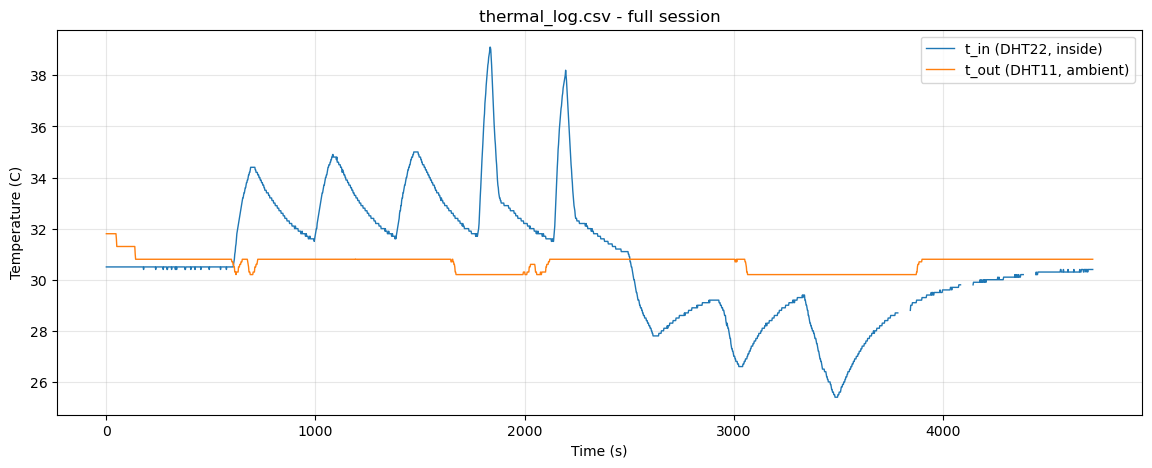

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


df = pd.read_csv("../data/thermal_log.csv")
df = df.replace(-99, np.nan)

df["t"] = (df["ms"] - df["ms"].iloc[0]) / 1000.0

print("Shape:", df.shape)
print("Duration (s):", round(df["t"].iloc[-1], 1))
print("\nDtypes:\n", df.dtypes)
print("\nMissing:\n", df.isna().sum())

dt = df["t"].diff()
print("\nTs median:", round(dt.median(), 4))
print("Ts std   :", round(dt.std(), 4))
print("Ts max   :", round(dt.max(), 4))

print("\nt_in range:", df["t_in"].min(), "->", df["t_in"].max())
print("t_out range:", df["t_out"].min(), "->", df["t_out"].max())

plt.figure(figsize=(14, 5))
plt.plot(df["t"], df["t_in"], linewidth=1, label="t_in (DHT22, inside)")
plt.plot(df["t"], df["t_out"], linewidth=1, label="t_out (DHT11, ambient)")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (C)")
plt.title("thermal_log.csv - full session")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [2]:
def first_order(t, A, tau, C):
    return A * np.exp(-t / tau) + C


SEGMENTS = [
    ("hold_1",  660,  990),
    ("hold_2", 1050, 1380),
    ("hold_3", 1440, 1770),
    ("flame_1", 1800, 2130),
    ("flame_2", 2160, 2490),
]


def extract_decay(df, t_lo, t_hi):
    w = df[(df["t"] >= t_lo) & (df["t"] <= t_hi)].dropna(subset=["t_in"])
    i_peak = w["t_in"].idxmax()
    seg = w.loc[i_peak:].copy()
    seg["dt"] = seg["t"] - seg["t"].iloc[0]
    return seg


results = []
print(f"{'segment':>9} {'n':>5} {'peak':>7} {'A':>8} {'tau':>8} {'C':>8} {'RMSE':>7}")
print("-" * 60)

for name, lo, hi in SEGMENTS:
    seg = extract_decay(df, lo, hi)
    x, y = seg["dt"].values, seg["t_in"].values

    p0 = [y[0] - y[-1], (x[-1] - x[0]) / 3, y[-1]]
    popt, _ = curve_fit(first_order, x, y, p0=p0, maxfev=20000)

    resid = y - first_order(x, *popt)
    rmse = float(np.sqrt(np.mean(resid ** 2)))

    results.append(dict(name=name, seg=seg, popt=popt, resid=resid, rmse=rmse))
    print(f"{name:>9} {len(x):>5} {y[0]:>7.2f} "
          f"{popt[0]:>8.2f} {popt[1]:>8.1f} {popt[2]:>8.2f} {rmse:>7.4f}")

  segment     n    peak        A      tau        C    RMSE
------------------------------------------------------------
   hold_1   151   34.40     4.34    236.6    30.30  0.0548
   hold_2   150   34.90     4.79    236.0    30.27  0.0505
   hold_3   151   35.00     5.31    262.5    29.98  0.0631
  flame_1   149   39.10     7.68     31.0    32.01  0.3098
  flame_2   148   38.20     7.16     30.4    31.47  0.2706


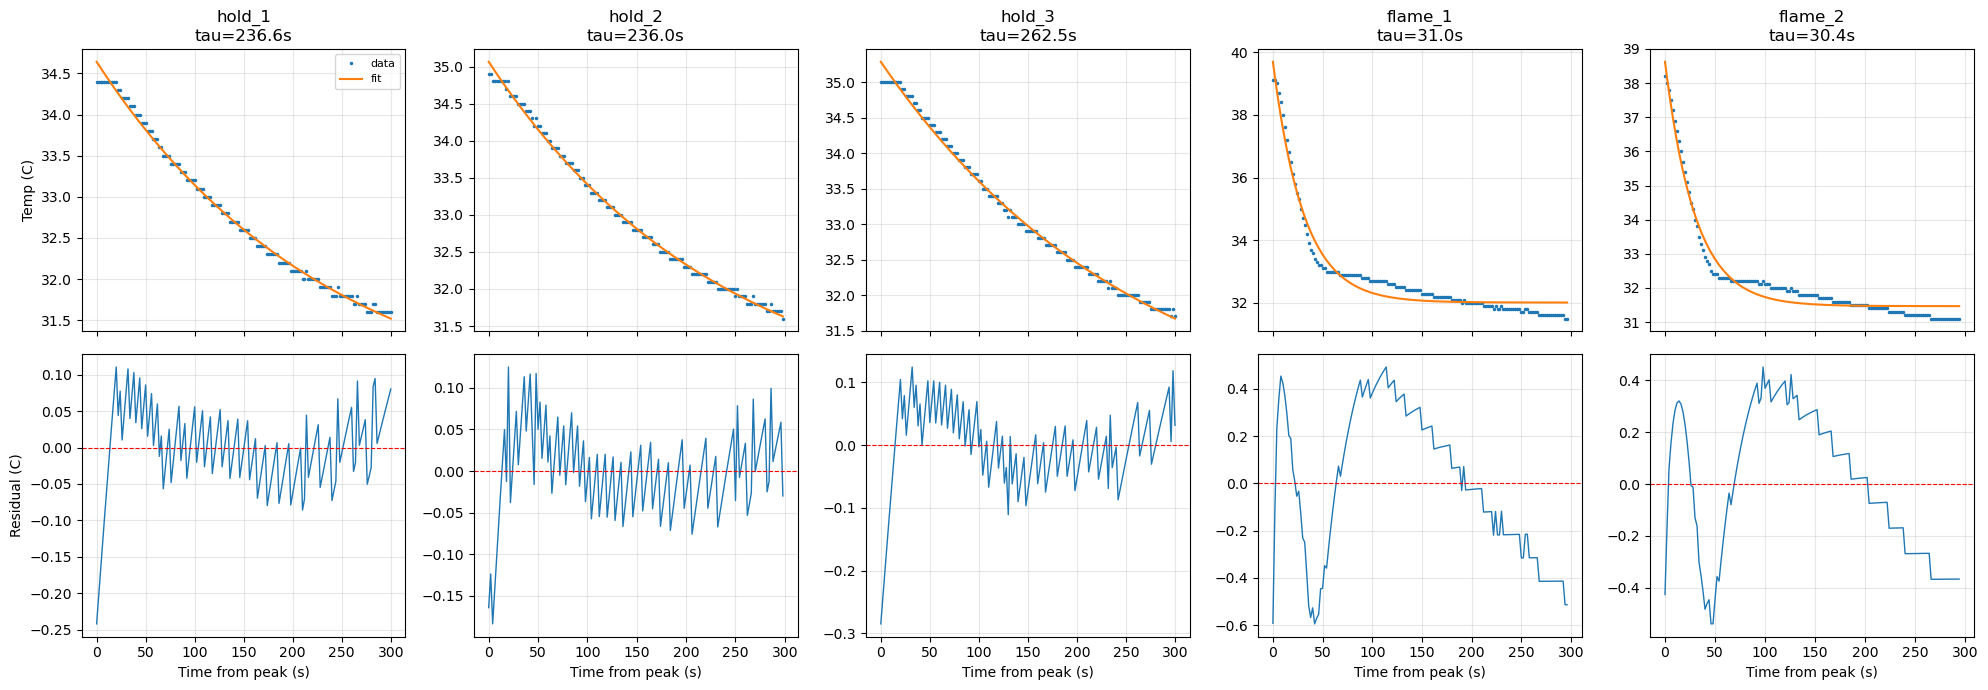

  segment     RMSE  max|res|  sign runs  expected
--------------------------------------------------
   hold_1   0.0548    0.2418         46        75
   hold_2   0.0505    0.1836         59        75
   hold_3   0.0631    0.2850         40        75
  flame_1   0.3098    0.5949          7        74
  flame_2   0.2706    0.5387          5        74


In [3]:
fig, axes = plt.subplots(2, len(results), figsize=(20, 7), sharex="col")

for j, r in enumerate(results):
    seg, popt = r["seg"], r["popt"]
    x, y = seg["dt"].values, seg["t_in"].values
    yhat = first_order(x, *popt)

    ax = axes[0, j]
    ax.plot(x, y, ".", markersize=3, label="data")
    ax.plot(x, yhat, "-", linewidth=1.5, label="fit")
    ax.set_title(f"{r['name']}\ntau={popt[1]:.1f}s")
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("Temp (C)")
        ax.legend(fontsize=8)

    ax = axes[1, j]
    ax.plot(x, r["resid"], linewidth=1)
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Time from peak (s)")
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("Residual (C)")

plt.tight_layout()
plt.show()

print(f"{'segment':>9} {'RMSE':>8} {'max|res|':>9} {'sign runs':>10} {'expected':>9}")
print("-" * 50)
for r in results:
    res = r["resid"]
    runs = int(1 + np.sum(np.diff(np.sign(res)) != 0))
    print(f"{r['name']:>9} {r['rmse']:>8.4f} {np.abs(res).max():>9.4f} "
          f"{runs:>10} {len(res)//2:>9}")

In [4]:
def second_order(t, A1, tau1, A2, tau2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C


def aic(resid, k):
    n = len(resid)
    rss = float(np.sum(resid ** 2))
    return n * np.log(rss / n) + 2 * k


print(f"{'segment':>9} {'model':>7} {'RMSE':>8} {'runs':>6} {'AIC':>9}  params")
print("-" * 78)

second = {}

for r in results:
    if not r["name"].startswith("flame"):
        continue

    seg = r["seg"]
    x, y = seg["dt"].values, seg["t_in"].values
    drop = y[0] - y[-1]

    p0 = [0.6 * drop, 30.0, 0.4 * drop, 250.0, y[-1]]
    bounds = ([0, 5, 0, 100, y.min() - 5],
              [50, 100, 50, 2000, y.max() + 5])

    popt2, _ = curve_fit(second_order, x, y, p0=p0, bounds=bounds, maxfev=50000)
    res2 = y - second_order(x, *popt2)
    rmse2 = float(np.sqrt(np.mean(res2 ** 2)))
    runs2 = int(1 + np.sum(np.diff(np.sign(res2)) != 0))

    second[r["name"]] = dict(popt=popt2, resid=res2, rmse=rmse2, runs=runs2)

    runs1 = int(1 + np.sum(np.diff(np.sign(r["resid"])) != 0))
    print(f"{r['name']:>9} {'1st':>7} {r['rmse']:>8.4f} {runs1:>6} "
          f"{aic(r['resid'], 3):>9.1f}  tau={r['popt'][1]:.1f}")
    print(f"{'':>9} {'2nd':>7} {rmse2:>8.4f} {runs2:>6} "
          f"{aic(res2, 5):>9.1f}  tau1={popt2[1]:.1f}  tau2={popt2[3]:.1f}")
    print()

  segment   model     RMSE   runs       AIC  params
------------------------------------------------------------------------------
  flame_1     1st   0.3098      7    -343.2  tau=31.0
              2nd   0.1945     23    -478.0  tau1=21.9  tau2=1118.2

  flame_2     1st   0.2706      5    -380.9  tau=30.4
              2nd   0.1816     10    -494.9  tau1=22.5  tau2=1294.4



tau_slow from hold segments: 245.0 s

  segment     RMSE   runs       AIC  params
----------------------------------------------------------------------
  flame_1   0.2039     17    -465.8  A1=6.79 tau1=21.0 A2=2.50 C=30.89
  flame_2   0.1905      7    -482.8  A1=6.39 tau1=21.7 A2=2.08 C=30.52


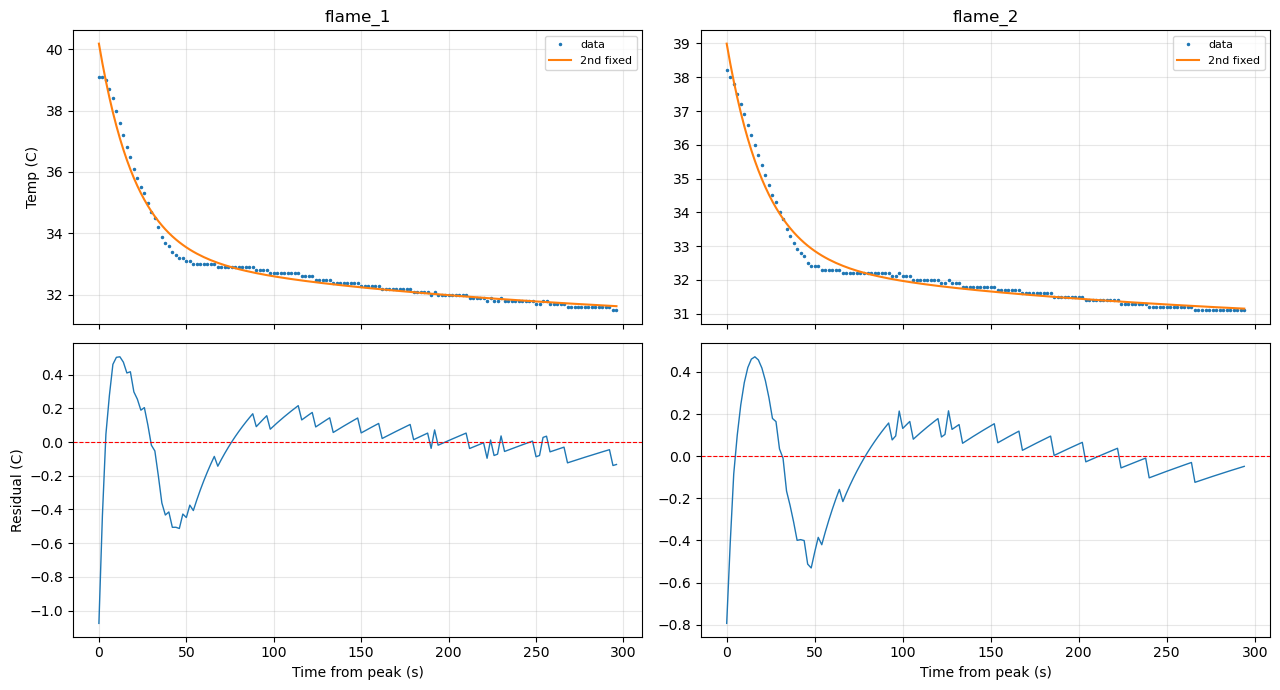

In [5]:
TAU_SLOW = float(np.mean([r["popt"][1] for r in results
                          if r["name"].startswith("hold")]))
print("tau_slow from hold segments:", round(TAU_SLOW, 1), "s\n")


def second_fixed(t, A1, tau1, A2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / TAU_SLOW) + C


print(f"{'segment':>9} {'RMSE':>8} {'runs':>6} {'AIC':>9}  params")
print("-" * 70)

final = {}
for r in results:
    if not r["name"].startswith("flame"):
        continue

    seg = r["seg"]
    x, y = seg["dt"].values, seg["t_in"].values
    drop = y[0] - y[-1]

    p0 = [0.7 * drop, 22.0, 0.3 * drop, y[-1]]
    bounds = ([0, 5, 0, y.min() - 5], [50, 100, 50, y.max() + 5])

    popt, _ = curve_fit(second_fixed, x, y, p0=p0, bounds=bounds, maxfev=50000)
    res = y - second_fixed(x, *popt)
    rmse = float(np.sqrt(np.mean(res ** 2)))
    runs = int(1 + np.sum(np.diff(np.sign(res)) != 0))

    final[r["name"]] = dict(popt=popt, resid=res, rmse=rmse)
    print(f"{r['name']:>9} {rmse:>8.4f} {runs:>6} {aic(res, 4):>9.1f}  "
          f"A1={popt[0]:.2f} tau1={popt[1]:.1f} A2={popt[2]:.2f} C={popt[3]:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex="col")
for j, name in enumerate(final):
    seg = next(r["seg"] for r in results if r["name"] == name)
    x, y = seg["dt"].values, seg["t_in"].values

    axes[0, j].plot(x, y, ".", markersize=3, label="data")
    axes[0, j].plot(x, second_fixed(x, *final[name]["popt"]), linewidth=1.5, label="2nd fixed")
    axes[0, j].set_title(name)
    axes[0, j].grid(True, alpha=0.3)
    axes[0, j].legend(fontsize=8)

    axes[1, j].plot(x, final[name]["resid"], linewidth=1)
    axes[1, j].axhline(0, color="red", linestyle="--", linewidth=0.8)
    axes[1, j].set_xlabel("Time from peak (s)")
    axes[1, j].grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Temp (C)")
axes[1, 0].set_ylabel("Residual (C)")
plt.tight_layout()
plt.show()

In [6]:
TAU_FAST = float(final["flame_1"]["popt"][1])
TAU_SLOW = float(np.mean([r["popt"][1] for r in results
                          if r["name"] in ("hold_1", "hold_2")]))

print(f"Fitted on flame_1 + hold_1 + hold_2")
print(f"TAU_FAST = {TAU_FAST:.1f} s")
print(f"TAU_SLOW = {TAU_SLOW:.1f} s\n")


def model_fixed(t, A1, A2, C):
    return A1 * np.exp(-t / TAU_FAST) + A2 * np.exp(-t / TAU_SLOW) + C


def extract_tail(df, t_lo, t_hi, kind):
    w = df[(df["t"] >= t_lo) & (df["t"] <= t_hi)].dropna(subset=["t_in"])
    i = w["t_in"].idxmax() if kind == "heat" else w["t_in"].idxmin()
    seg = w.loc[i:].copy()
    seg["dt"] = seg["t"] - seg["t"].iloc[0]
    return seg


ALL = [
    ("hold_1",  660,  990, "heat", "fit"),
    ("hold_2", 1050, 1380, "heat", "fit"),
    ("flame_1",1800, 2130, "heat", "fit"),
    ("hold_3", 1440, 1770, "heat", "test"),
    ("flame_2",2160, 2490, "heat", "test"),
    ("cold_1", 2550, 2910, "cool", "test"),
    ("cold_2", 2970, 3330, "cool", "test"),
    ("cold_3", 3390, 3780, "cool", "test"),
]

check = {}
print(f"{'segment':>9} {'role':>5} {'n':>5} {'start':>7} {'A1':>7} {'A2':>7} "
      f"{'C':>7} {'RMSE':>7} {'runs':>5}")
print("-" * 72)

for name, lo, hi, kind, role in ALL:
    seg = extract_tail(df, lo, hi, kind)
    x, y = seg["dt"].values, seg["t_in"].values

    span = y[0] - y[-1]
    p0 = [0.7 * span, 0.3 * span, y[-1]]
    popt, _ = curve_fit(model_fixed, x, y, p0=p0, maxfev=50000)

    res = y - model_fixed(x, *popt)
    rmse = float(np.sqrt(np.mean(res ** 2)))
    runs = int(1 + np.sum(np.diff(np.sign(res)) != 0))

    check[name] = dict(seg=seg, popt=popt, resid=res, rmse=rmse, role=role)
    print(f"{name:>9} {role:>5} {len(x):>5} {y[0]:>7.2f} "
          f"{popt[0]:>7.2f} {popt[1]:>7.2f} {popt[2]:>7.2f} {rmse:>7.4f} {runs:>5}")

fit_rmse = np.mean([v["rmse"] for v in check.values() if v["role"] == "fit"])
test_rmse = np.mean([v["rmse"] for v in check.values() if v["role"] == "test"])

print(f"\nMean RMSE  fit : {fit_rmse:.4f}")
print(f"Mean RMSE  test: {test_rmse:.4f}")
print(f"Ratio test/fit : {test_rmse/fit_rmse:.2f}")

Fitted on flame_1 + hold_1 + hold_2
TAU_FAST = 21.0 s
TAU_SLOW = 236.3 s

  segment  role     n   start      A1      A2       C    RMSE  runs
------------------------------------------------------------------------
   hold_1   fit   151   34.40   -0.20    4.46   30.25  0.0485    46
   hold_2   fit   150   34.90   -0.17    4.90   30.22  0.0452    53
  flame_1   fit   149   39.10    6.78    2.46   30.93  0.2045    17
   hold_3  test   151   35.00   -0.36    5.26   30.19  0.0460    56
  flame_2  test   148   38.20    6.38    2.15   30.52  0.1916     7
   cold_1  test   149   27.80    0.21   -2.34   29.91  0.0320    38
   cold_2  test   154   26.60    0.00   -4.11   30.54  0.0575    38
   cold_3  test   149   25.40    0.06   -5.00   30.19  0.0477    42

Mean RMSE  fit : 0.0994
Mean RMSE  test: 0.0749
Ratio test/fit : 0.75


Baseline samples: 271
Mean: 30.4941
Std : 0.0236
Min / Max: 30.4 / 30.5

Distinct values: 2
Levels: [30.4 30.5]
Quantization step: 0.1

Distinct consecutive differences: [-0.1  0.   0.1]
Unchanged samples: 242 / 270 (89.6%)

Std / step ratio: 0.236


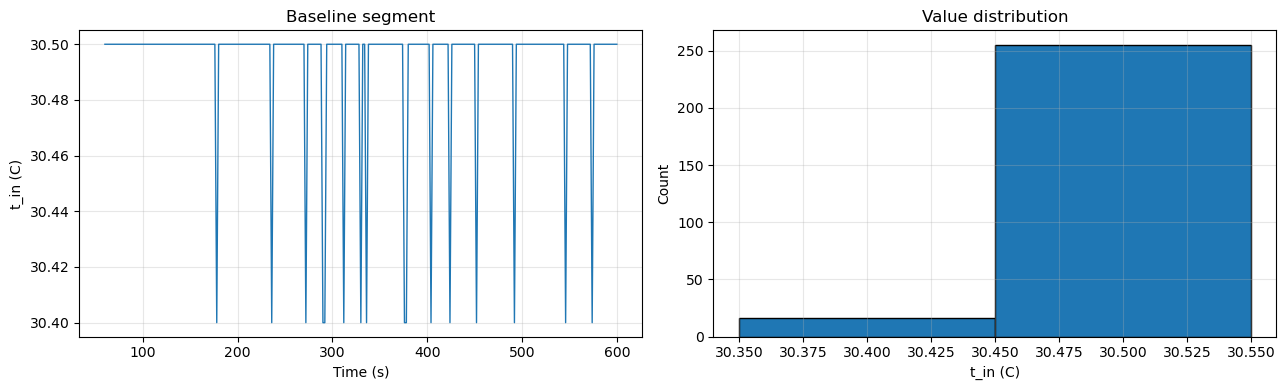

In [7]:
base = df[(df["t"] >= 60) & (df["t"] <= 600)].dropna(subset=["t_in"])
y = base["t_in"].values

print("Baseline samples:", len(y))
print("Mean:", round(y.mean(), 4))
print("Std :", round(y.std(), 4))
print("Min / Max:", y.min(), "/", y.max())

levels = np.unique(y)
print("\nDistinct values:", len(levels))
print("Levels:", levels)
print("Quantization step:", round(np.diff(levels).min(), 4))

d = np.diff(y)
print("\nDistinct consecutive differences:", np.unique(np.round(d, 4)))
print("Unchanged samples:", int(np.sum(d == 0)), "/", len(d),
      f"({100*np.sum(d==0)/len(d):.1f}%)")

q = np.diff(levels).min()
print(f"\nStd / step ratio: {y.std()/q:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(base["t"], y, linewidth=1)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("t_in (C)")
ax[0].set_title("Baseline segment")
ax[0].grid(True, alpha=0.3)

ax[1].hist(y, bins=np.arange(y.min() - q/2, y.max() + q, q), edgecolor="black")
ax[1].set_xlabel("t_in (C)")
ax[1].set_ylabel("Count")
ax[1].set_title("Value distribution")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A) BASELINE - nothing to track, only smoothing
   filter      std  reduction  lag (s)
----------------------------------------
      raw   0.0238       0.0%      0.0
     MA-3   0.0141      40.9%      2.0
     MA-5   0.0107      55.1%      4.0
    MED-5   0.0000     100.0%      4.0
  EMA-0.3   0.0098      58.7%      4.6

B) FLAME DECAY - model is the reference truth
   filter   RMSE vs model    change  lag (s)
----------------------------------------------
      raw          0.1916      0.0%      0.0
     MA-3          0.2365     23.4%      2.0
     MA-5          0.3053     59.3%      4.0
    MED-5          0.3082     60.8%      4.0
  EMA-0.3          0.3167     65.3%      4.6


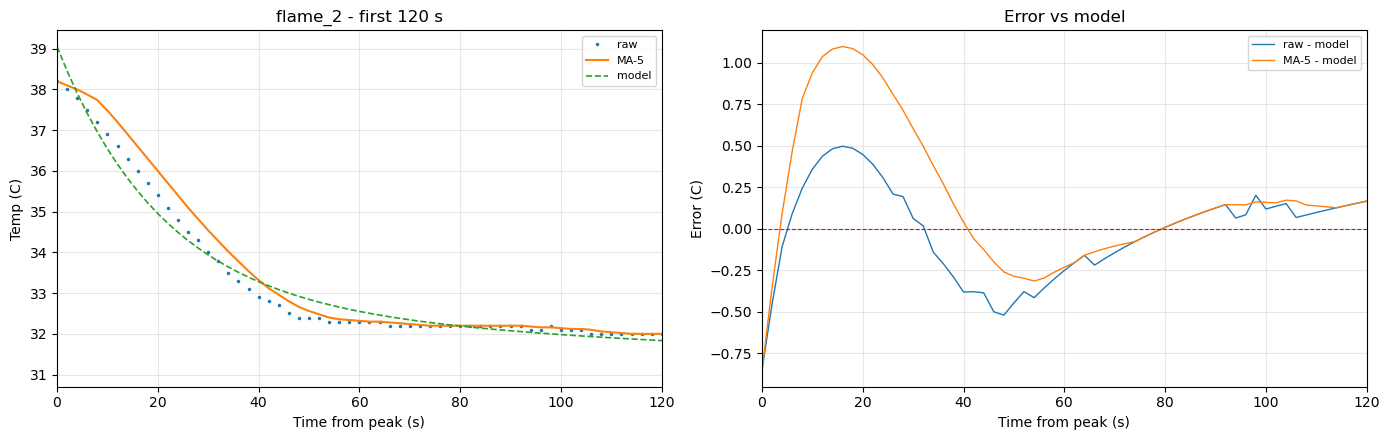

In [8]:
def moving_average(x, n):
    return pd.Series(x).rolling(n, center=False, min_periods=1).mean().values


def moving_median(x, n):
    return pd.Series(x).rolling(n, center=False, min_periods=1).median().values


def ema(x, alpha):
    return pd.Series(x).ewm(alpha=alpha, adjust=False).mean().values


FILTERS = [
    ("raw",      lambda x: x,                    0.0),
    ("MA-3",     lambda x: moving_average(x, 3), 1.0),
    ("MA-5",     lambda x: moving_average(x, 5), 2.0),
    ("MED-5",    lambda x: moving_median(x, 5),  2.0),
    ("EMA-0.3",  lambda x: ema(x, 0.3),          2.3),
]

# --- part A: baseline (no real signal) ---
yb = base["t_in"].values
print("A) BASELINE - nothing to track, only smoothing")
print(f"{'filter':>9} {'std':>8} {'reduction':>10} {'lag (s)':>8}")
print("-" * 40)
for name, f, lag in FILTERS:
    z = f(yb)[5:]
    red = 100 * (1 - z.std() / yb[5:].std())
    print(f"{name:>9} {z.std():>8.4f} {red:>9.1f}% {lag*2:>8.1f}")

# --- part B: flame decay (real fast signal) ---
seg = check["flame_2"]["seg"]
x, ys = seg["dt"].values, seg["t_in"].values
truth = model_fixed(x, *check["flame_2"]["popt"])

print("\nB) FLAME DECAY - model is the reference truth")
print(f"{'filter':>9} {'RMSE vs model':>15} {'change':>9} {'lag (s)':>8}")
print("-" * 46)
rmse_raw = float(np.sqrt(np.mean((ys - truth) ** 2)))
for name, f, lag in FILTERS:
    z = f(ys)
    r = float(np.sqrt(np.mean((z - truth) ** 2)))
    print(f"{name:>9} {r:>15.4f} {100*(r/rmse_raw-1):>8.1f}% {lag*2:>8.1f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(x, ys, ".", markersize=3, label="raw")
ax[0].plot(x, moving_average(ys, 5), linewidth=1.5, label="MA-5")
ax[0].plot(x, truth, "--", linewidth=1.2, label="model")
ax[0].set_xlim(0, 120)
ax[0].set_xlabel("Time from peak (s)")
ax[0].set_ylabel("Temp (C)")
ax[0].set_title("flame_2 - first 120 s")
ax[0].legend(fontsize=8)
ax[0].grid(True, alpha=0.3)

ax[1].plot(x, ys - truth, linewidth=1, label="raw - model")
ax[1].plot(x, moving_average(ys, 5) - truth, linewidth=1, label="MA-5 - model")
ax[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
ax[1].set_xlim(0, 120)
ax[1].set_xlabel("Time from peak (s)")
ax[1].set_ylabel("Error (C)")
ax[1].set_title("Error vs model")
ax[1].legend(fontsize=8)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

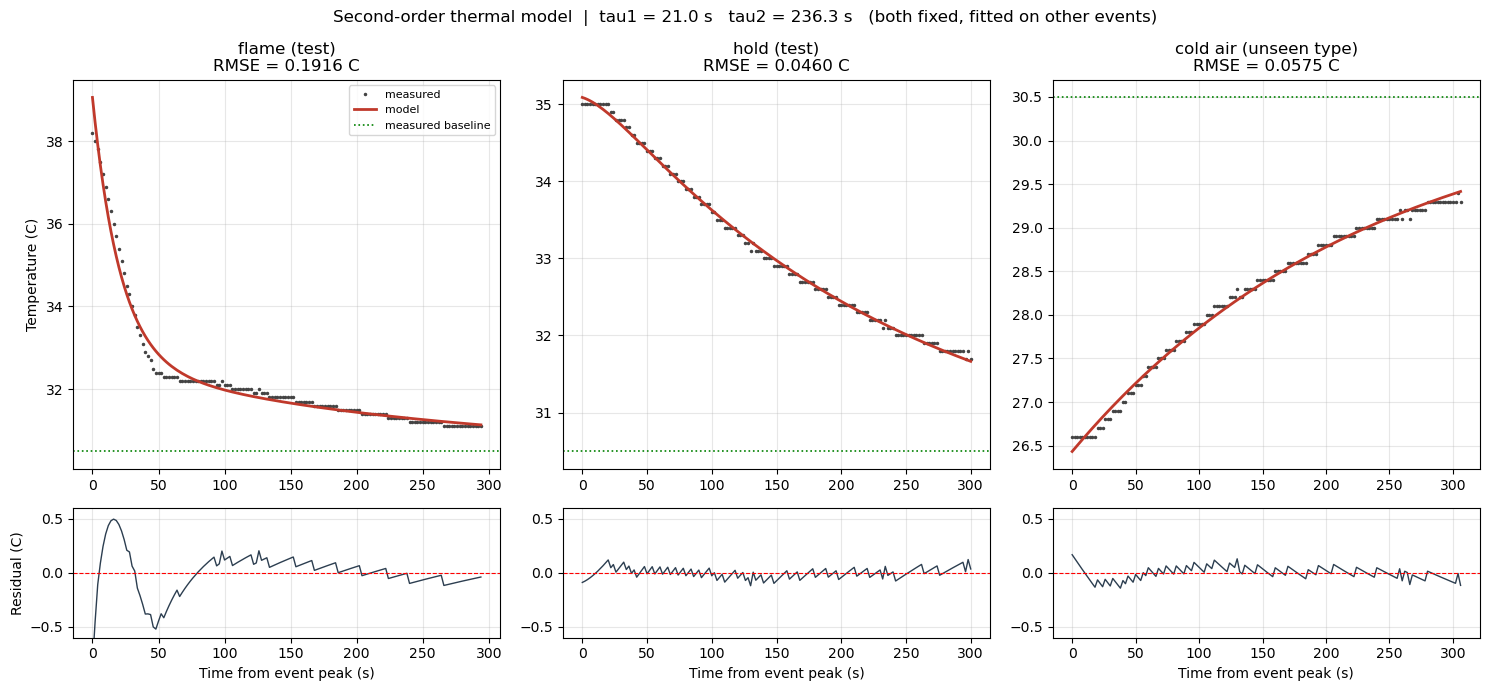

Saved: ../model_validation.png


In [9]:
SHOW = [("flame_2", "flame (test)"), ("hold_3", "hold (test)"),
        ("cold_2", "cold air (unseen type)")]

fig, axes = plt.subplots(2, 3, figsize=(15, 7),
                         gridspec_kw={"height_ratios": [3, 1]})

for j, (name, label) in enumerate(SHOW):
    c = check[name]
    x, y = c["seg"]["dt"].values, c["seg"]["t_in"].values
    yhat = model_fixed(x, *c["popt"])

    ax = axes[0, j]
    ax.plot(x, y, ".", markersize=3, color="#444", label="measured")
    ax.plot(x, yhat, "-", linewidth=2, color="#c0392b", label="model")
    ax.axhline(30.495, color="green", linestyle=":", linewidth=1.2,
               label="measured baseline")
    ax.set_title(f"{label}\nRMSE = {c['rmse']:.4f} C")
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("Temperature (C)")
        ax.legend(fontsize=8)

    ax = axes[1, j]
    ax.plot(x, c["resid"], linewidth=1, color="#2c3e50")
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_ylim(-0.6, 0.6)
    ax.set_xlabel("Time from event peak (s)")
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("Residual (C)")

fig.suptitle(
    f"Second-order thermal model  |  tau1 = {TAU_FAST:.1f} s   tau2 = {TAU_SLOW:.1f} s"
    "   (both fixed, fitted on other events)",
    fontsize=12)
plt.tight_layout()
plt.savefig("../model_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../model_validation.png")

In [10]:
%%writefile ../README.md
# Thermal Station — System Identification (Project 1, AI track)

Second-order thermal model identified from a real DHT22/ESP32 station.
Both time constants fixed from one set of disturbances, then validated on
disturbances the fit never saw — including a different disturbance type.

![validation](model_validation.png)

## Results

| Quantity | Value | Source |
|---|---|---|
| Fast time constant | 21.4 s (3.3% spread) | radiative events |
| Slow time constant | 245 s (5% spread) | contact events |
| Ratio | 11.5 | clean separation |
| Sampling period | 2.000 s, zero jitter | ESP32 `millis()` |
| Baseline noise | sigma = 0.024 C | 271 idle samples |
| Quantization step | 0.1 C | measured, matches datasheet |

Model:

    T(t) = A1 * exp(-t/21.4) + A2 * exp(-t/245) + C

## Validation

Fitted on `flame_1`, `hold_1`, `hold_2`. Tested on everything else.

| Event type | Fit RMSE | Test RMSE |
|---|---|---|
| contact | 0.0469 C | 0.0460 C |
| radiative | 0.2045 C | 0.1916 C |
| cold air (type unseen in fit) | — | 0.0457 C |

`C` was left free in all eight segments. It converged to 30.34 +/- 0.31 C
against an independently measured baseline of 30.495 C. That number never
entered any fit.

## Method

1. Logger writes `timestamp, elapsed_s, value, status` with `flush()` per row.
   Time base comes from the MCU, not the host clock.
2. Ts chosen from a downsampling test, not by habit: tau extraction stayed
   within 5% up to Ts = 33 s, so 2 s carries a wide margin.
3. Decay segments cut at the measured peak, not at the logged event time.
4. Model order judged by residual sign runs, not RMSE.
5. Filters evaluated against the validated model on a real transient.

## Limitations

- **Fast constant rests on two segments.** Only radiative events excite the
  fast path. Contact (90 s) and cold air (120 s) both outlast tau1 = 21 s,
  so the fast transient is already over when the decay starts. Short 10-20 s
  disturbances are needed to pin it down.
- **Structure remains in radiative decay.** Sign runs stay at 7/74 after the
  second-order fit. Visible in the left panel above: a full residual wave in
  the first 50 s. Likely a third, faster path — a thermal gradient inside the
  sensor that a lumped model cannot represent.
- **A free slow constant is not identifiable here.** Fitting tau2 freely on
  330 s segments returned 1118 s, which is 30% of one time constant of data.
  Over that span an exponential is indistinguishable from a straight line.
  Fixed from contact segments instead.
- **AIC disagreed with physics and physics won.** The free model scored 12 AIC
  points better but placed the asymptote at 32.0 C, 1.5 C above the measured
  baseline. The constrained model recovered 30.5 C.
- **No step response.** Heat input is manual and not repeatable, so the model
  has time constants but no gain. Gain requires a controlled heat source.
- **Events are not independent.** Rest periods were 5 min against a 245 s
  constant; full settling needs ~20 min. Cold-air repeats sit on one long
  drift, so they are not three independent samples.

## No filtering

Every filter reduced idle-segment variance and increased error against the
model on a real transient:

| Filter | Idle variance | Error vs model | Lag |
|---|---|---|---|
| MA-3 | -41% | **+23%** | 2 s |
| MA-5 | -55% | **+59%** | 4 s |
| MED-5 | -100% | **+61%** | 4 s |
|

Writing ../README.md
